# Homework 9

In [26]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


## Data Selection and Preparation

In [27]:
# Load the CSV file for the training dataset
data = pd.read_csv('world-data-2023.csv')
df = pd.DataFrame(data)

df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [28]:
# the list of columns i selected
child_df= df[['Infant mortality',
              'Out of pocket health expenditure',
              'Life expectancy', 'Co2-Emissions','Minimum wage','Unemployment rate',
              'Urban_population']]


In [65]:
# another dataframe with many attributes to compare the results
child_df_2 = df[[ 'Density\n(P/Km2)', 'Agricultural Land( %)', 'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Fertility Rate', 'Forested Area (%)',
       'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude']]

### Data cleaning

In [29]:
# Before interpolation
print("NAs before:",child_df.isna().sum().sum())

# Interpolate
child_df.interpolate(inplace=True) #fill Nas with interpolation

# Check results
print("NAs after:", child_df.isna().sum().sum())

# Drop the remaining missing values
child_df = child_df.dropna() 
child_df.isna().sum().sum() 


NAs before: 97
NAs after: 83


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_20413/3881318680.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  child_df.interpolate(inplace=True) #fill Nas with interpolation
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_20413/3881318680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df.interpolate(inplace=True) #fill Nas with interpolation


np.int64(0)

In [67]:
# Before interpolation
print("NAs before:",child_df_2.isna().sum().sum())

# Interpolate
child_df_2.interpolate(inplace=True)

# Check results
print("NAs after:", child_df_2.isna().sum().sum())

# Drop the remaining missing values
child_df_2 = child_df_2.dropna() 
child_df_2.isna().sum().sum() 


NAs before: 283
NAs after: 233


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/688898729.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  child_df_2.interpolate(inplace=True)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/688898729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2.interpolate(inplace=True)


np.int64(0)

### Convert all attributes to float

In [30]:
# convert values to float
child_df.dtypes

# changing to float by removing $ and/or %
child_df['Co2-Emissions'] = child_df['Co2-Emissions'].astype(str).str.replace(',', '').astype(float)
child_df['Minimum wage'] = child_df['Minimum wage'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
child_df['Urban_population'] = child_df['Urban_population'].astype(str).str.replace(',', '').astype(float)

# Remove '%' and convert to decimals
child_df['Out of pocket health expenditure'] = child_df['Out of pocket health expenditure'].astype(str).str.replace('%', '').astype(float) / 100
child_df['Unemployment rate'] = child_df['Unemployment rate'].astype(str).str.replace('%', '').astype(float) / 100


In [85]:

# changing to float by removing $ and/or %
child_df_2['GDP'] = child_df_2['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
child_df_2['Minimum wage'] = child_df_2['Minimum wage'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
child_df_2['Density\n(P/Km2)'] = child_df_2['Density\n(P/Km2)'].astype(str).str.replace(',', '').astype(float)
child_df_2['Armed Forces size'] = child_df_2['Armed Forces size'].astype(str).str.replace(',', '').astype(float)
child_df_2['Co2-Emissions'] = child_df_2['Co2-Emissions'].astype(str).str.replace(',', '').astype(float)
child_df_2['CPI'] = child_df_2['CPI'].astype(str).str.replace(',', '').astype(float)
child_df_2['Population'] = child_df_2['Population'].astype(str).str.replace(',', '').astype(float)
child_df_2['Urban_population'] = child_df_2['Urban_population'].astype(str).str.replace(',', '').astype(float)
child_df_2['Fertility Rate'] = child_df_2['Fertility Rate'].astype(float)

# Remove '%' and convert to decimals
child_df_2['Gross primary education enrollment (%)'] = child_df_2['Gross primary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Out of pocket health expenditure'] = child_df_2['Out of pocket health expenditure'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Unemployment rate'] = child_df_2['Unemployment rate'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Agricultural Land( %)'] = child_df_2['Agricultural Land( %)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['CPI Change (%)'] = child_df_2['CPI Change (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Forested Area (%)'] = child_df_2['Forested Area (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Gross tertiary education enrollment (%)'] = child_df_2['Gross tertiary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Population: Labor force participation (%)'] = child_df_2['Population: Labor force participation (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Tax revenue (%)'] = child_df_2['Tax revenue (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Total tax rate'] = child_df_2['Total tax rate'].astype(str).str.replace('%', '').astype(float) / 100
#เหลือเปอร์เซ้นต์


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/3773837257.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['GDP'] = child_df_2['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/3773837257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['Minimum wage'] = child_df_2['Minimum wage'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
/var/folders/34/91r13ymj4sv1

### Scaling the data

In [31]:
# Standardize the features (important for clustering)
scaler = StandardScaler()
child_df_scaled = scaler.fit_transform(child_df)

child_df_scaled

array([[ 1.30742805e+00,  2.35469113e+00, -1.02410405e+00,
        -2.24514371e-01, -5.72970820e-01,  9.02706282e-01,
        -2.12451203e-01],
       [-7.17423748e-01,  1.18975769e+00,  8.81071142e-01,
        -2.28822376e-01, -3.36002910e-01,  1.15872942e+00,
        -3.05663945e-01],
       [-9.63345421e-02, -3.70711295e-01,  6.36120045e-01,
        -7.73026620e-02, -3.94386308e-01,  1.02542812e+00,
         3.89764499e-02],
       [ 1.49425976e+00, -8.35416560e-02, -1.52761464e+00,
        -1.97411226e-01, -4.76809929e-01,  7.68324523e-03,
        -8.20205257e-02],
       [-6.66928690e-01, -9.39632279e-01,  6.08903257e-01,
        -2.38254836e-02,  4.29849899e-01,  6.21292420e-01,
         1.52798608e-01],
       [-5.55839564e-01,  2.52807657e+00,  3.91168949e-01,
        -2.28176592e-01, -4.93981517e-01,  2.14473589e+00,
        -3.04248271e-01],
       [-9.54750517e-01, -8.31266377e-01,  1.45262370e+00,
         1.57994007e-01,  3.94659105e+00, -3.35091535e-01,
        -7.2945169

In [87]:
# Standardize the features (important for clustering)
scaler = StandardScaler()
child_df_2_scaled = scaler.fit_transform(child_df_2)

child_df_2_scaled

array([[-0.42221022,  0.79200578,  0.33307705, ..., -0.23782231,
         0.57522513,  0.76318443],
       [-0.20306168,  0.05433753, -0.41339903, ..., -0.3250489 ,
         0.87374946, -0.01724009],
       [-0.62674886, -1.20953407,  0.31881318, ..., -0.00254139,
         0.33086711, -0.32107169],
       ...,
       [-0.61700892,  1.99686392, -0.38249397, ..., -0.30819019,
        -2.17496615, -1.26374542],
       [ 0.81476154, -0.13253843,  0.80616221, ...,  0.03887436,
        -0.24744129,  1.42912034],
       [-0.59265908, -0.48661919, -0.39675784, ..., -0.25868774,
        -1.37265471,  0.10884819]], shape=(122, 26))

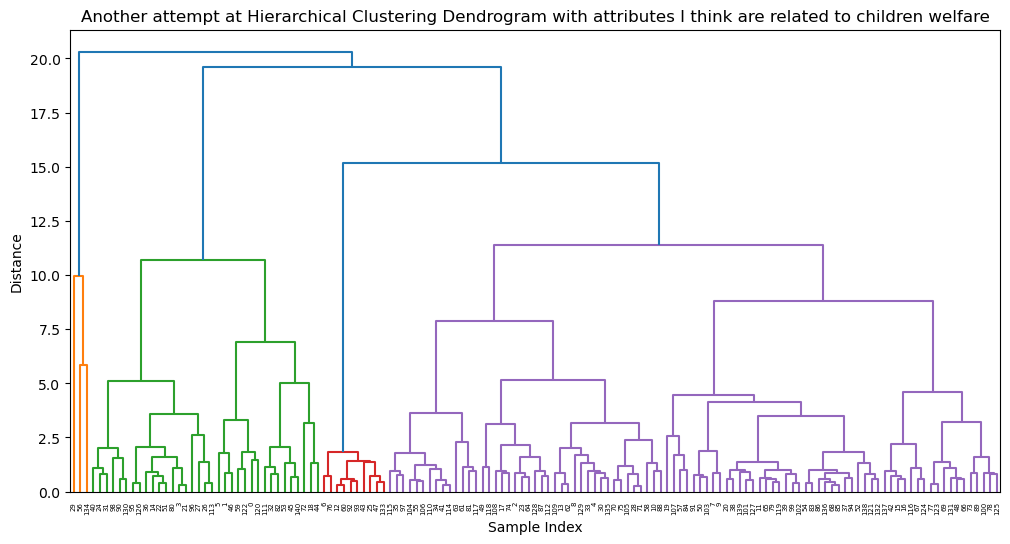

cluster
0    103
2     35
1      3
Name: count, dtype: int64
         Infant mortality  Out of pocket health expenditure  Life expectancy  \
cluster                                                                        
0               13.640777                          0.297883        74.932039   
1               14.300000                          0.362000        74.966667   
2               47.291429                          0.500000        63.220000   

         Co2-Emissions  Minimum wage  Unemployment rate  Urban_population  
cluster                                                                    
0         1.313200e+05      2.618058           0.062909      1.902880e+07  
1         5.769004e+06      2.806667           0.081267      5.282095e+08  
2         2.235326e+04      0.508286           0.084009      1.210663e+07  


In [37]:
# Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
child_df['cluster'] = clustering.fit_predict(child_df_scaled)

# Create dendrogram to visualize
plt.figure(figsize=(12, 6))
Z = linkage(child_df_scaled, method='ward')
dendrogram(Z)
plt.title('Another attempt at Hierarchical Clustering Dendrogram with attributes I think are related to children welfare')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# View cluster assignments
print(child_df['cluster'].value_counts())
print(child_df.groupby('cluster').mean())

/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/1367190556.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['cluster'] = clustering.fit_predict(child_df_2_scaled)


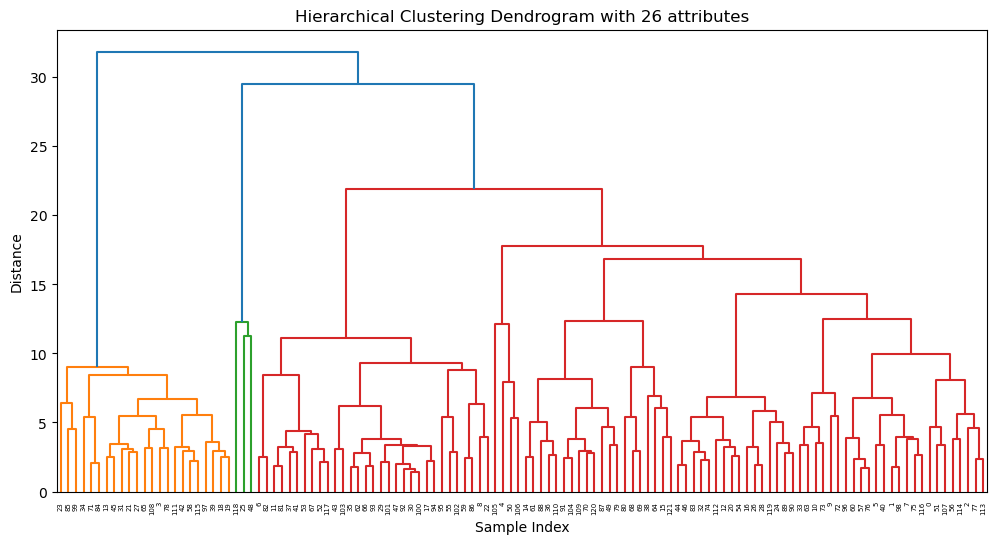

cluster
0    96
1    23
2     3
Name: count, dtype: int64
         Density\n(P/Km2)  Agricultural Land( %)  Armed Forces size  \
cluster                                                               
0              158.750000               0.000041       1.506667e+05   
1               87.130435               0.000045       3.321739e+04   
2              217.666667               0.000054       2.361667e+06   

         Birth Rate  Co2-Emissions         CPI  CPI Change (%)  \
cluster                                                          
0         16.920000   1.405069e+05  159.603438        0.000476   
1         36.193043   1.203278e+04  161.797391        0.000590   
2         13.453333   5.769004e+06  140.920000        0.000603   

         Fertility Rate  Forested Area (%)           GDP  ...  \
cluster                                                   ...   
0              2.214687           0.002975  4.089354e+11  ...   
1              4.861739           0.003563  4.723522e+10  ..

In [90]:
# Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
child_df_2['cluster'] = clustering.fit_predict(child_df_2_scaled)

# Create dendrogram to visualize
plt.figure(figsize=(12, 6))
Z = linkage(child_df_2_scaled, method='ward')
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram with 26 attributes')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# View cluster assignments
print(child_df_2['cluster'].value_counts())
print(child_df_2.groupby('cluster').mean())

In [36]:
# View countries in each cluster with names
for cluster_num in range(5):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_num}")
    print(f"{'='*50}")
    cluster_indices = child_df[child_df['cluster'] == cluster_num].index
    countries = df.loc[cluster_indices, 'Country']  # Adjust 'Country' to match your column name
    print(countries.tolist())


CLUSTER 0
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Azerbaijan', 'The Bahamas', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Ivory Coast', 'Cape Verde', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'Colombia', 'Comoros', 'Republic of the Congo', 'Costa Rica', 'Croatia', 'Czech Republic', 'Democratic Republic of the Congo', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Estonia', 'Fiji', 'France', 'Gabon', 'The Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Indonesia', 'Iran', 'Iraq', 'Republic of Ireland', 'Israel', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Mal

In [89]:
# View countries in each cluster with names
for cluster_num in range(3):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_num}")
    print(f"{'='*50}")
    cluster_indices = child_df_2[child_df_2['cluster'] == cluster_num].index
    countries = df.loc[cluster_indices, 'Country']  # Adjust 'Country' to match your column name
    print(countries.tolist())


CLUSTER 0
['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Azerbaijan', 'The Bahamas', 'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Bhutan', 'Botswana', 'Brazil', 'Bulgaria', 'Cape Verde', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Dominican Republic', 'El Salvador', 'Estonia', 'Fiji', 'France', 'Gabon', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Honduras', 'Hungary', 'Indonesia', 'Iran', 'Iraq', 'Republic of Ireland', 'Israel', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Morocco', 'Myanmar', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Oman', 'Pakistan', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Serbia', 'Slovakia', 'Slovenia', 'South Korea', 'Spain', 'Sri Lank